# 03 — Exploratory Data Analysis

## Smart India Real Estate Analytics

### Objective

The objective of this notebook is to explore the distributions, patterns, relationships, and potential anomalies present in the real-estate dataset.

The analysis will focus on understanding the target variable, numerical variables, categorical variables, text fields, and their relationships with property price.

### EDA Scope

This notebook will investigate:

- Distribution of `Price`
- Distribution of `Total_Area` and `Baths`
- Distribution of `Price_per_SQFT` for exploratory purposes
- Location and Balcony distributions
- Relationships between potential predictors and `Price`
- Price differences across locations
- Potential anomalies and extreme observations
- Information contained in text-based property fields

### Important Data Integrity Rules

- The raw dataset is treated as immutable.
- No rows or columns will be deleted.
- No target values will be modified.
- No preprocessing pipeline will be created.
- No final feature engineering will be performed.
- No model training will be performed.
- `Price_per_SQFT` will be treated as target-derived and will not be considered a predictive feature.

EDA findings will be used to guide later feature engineering and preprocessing decisions.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("../data/raw/Real Estate Data V21.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset shape: (14528, 9)
Rows: 14,528
Columns: 9


In [42]:
df.head()

,Name,Property Title,Price,Location,Total_Area,Price_per_SQFT,Description,Baths,Balcony
0,Casagrand ECR 14,"4 BHK Flat for sale in Kanathur Reddikuppam, C...",₹1.99 Cr,"Kanathur Reddikuppam, Chennai",2583,7700.0,Best 4 BHK Apartment for modern-day lifestyle ...,4,Yes
1,"Ramanathan Nagar, Pozhichalur,Chennai",10 BHK Independent House for sale in Pozhichal...,₹2.25 Cr,"Ramanathan Nagar, Pozhichalur,Chennai",7000,3210.0,Looking for a 10 BHK Independent House for sal...,6,Yes
2,DAC Prapthi,"3 BHK Flat for sale in West Tambaram, Chennai",₹1.0 Cr,"Kasthuribai Nagar, West Tambaram,Chennai",1320,7580.0,"Property for sale in Tambaram, Chennai. This 3...",3,No
3,"Naveenilaya,Chepauk, Triplicane,Chennai",7 BHK Independent House for sale in Triplicane...,₹3.33 Cr,"Naveenilaya,Chepauk, Triplicane,Chennai",4250,7840.0,Entire Building for sale with 7 units of singl...,5,Yes
4,VGN Spring Field Phase 1,"2 BHK Flat for sale in Avadi, Chennai",₹48.0 L,"Avadi, Chennai",960,5000.0,"Property for sale in Avadi, Chennai. This 2 BH...",3,Yes


In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14528 entries, 0 to 14527
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            14528 non-null  str    
 1   Property Title  14528 non-null  str    
 2   Price           14528 non-null  str    
 3   Location        14528 non-null  str    
 4   Total_Area      14528 non-null  int64  
 5   Price_per_SQFT  14528 non-null  float64
 6   Description     14528 non-null  str    
 7   Baths           14528 non-null  int64  
 8   Balcony         14528 non-null  str    
dtypes: float64(1), int64(2), str(6)
memory usage: 1021.6 KB


In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Total_Area,14528.0,1297.916988,1245.694305,70.0,650.0,1000.0,1439.0,35000.0
Price_per_SQFT,14528.0,11719.456222,49036.068632,0.0,4480.0,6050.0,9312.5,999000.0
Baths,14528.0,2.751239,0.898243,1.0,2.0,3.0,3.0,6.0


In [45]:
def parse_price_for_eda(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip().replace("₹", "").replace(",", "").lower()

    try:
        if "cr" in value:
            return float(value.replace("cr", "").strip()) * 10_000_000

        elif "lacs" in value:
            return float(value.replace("lacs", "").strip()) * 100_000

        elif "lac" in value:
            return float(value.replace("lac", "").strip()) * 100_000

        elif "k" in value:
            return float(value.replace("k", "").strip()) * 1_000

        elif "l" in value:
            return float(value.replace("l", "").strip()) * 100_000

        else:
            return np.nan

    except ValueError:
        return np.nan


price_numeric_eda = df["Price"].apply(parse_price_for_eda)

print(f"Successfully parsed: {price_numeric_eda.notna().sum():,}")
print(f"Unparsed/ambiguous: {price_numeric_eda.isna().sum():,}")

Successfully parsed: 14,525
Unparsed/ambiguous: 3


In [46]:
unparsed_price_values = df.loc[
    price_numeric_eda.isna(),
    ["Price", "Total_Area", "Price_per_SQFT"]
]

unparsed_price_values

,Price,Total_Area,Price_per_SQFT
4277,₹2.0,3000,0.0
5856,₹3.0,2800,0.0
7948,₹1.0,1800,0.0


In [47]:
price_numeric_eda.describe()

count    1.452500e+04
mean     1.067464e+07
std      1.867463e+07
min      5.500000e+04
25%      3.700000e+06
50%      6.500000e+06
75%      1.140000e+07
max      8.400000e+08
Name: Price, dtype: float64

## Price Distribution

The distribution of the target variable is examined to understand its central tendency, spread, skewness, and potential extreme observations.

The analysis uses the temporary numeric `price_numeric_eda` representation. The raw `Price` column remains unchanged.

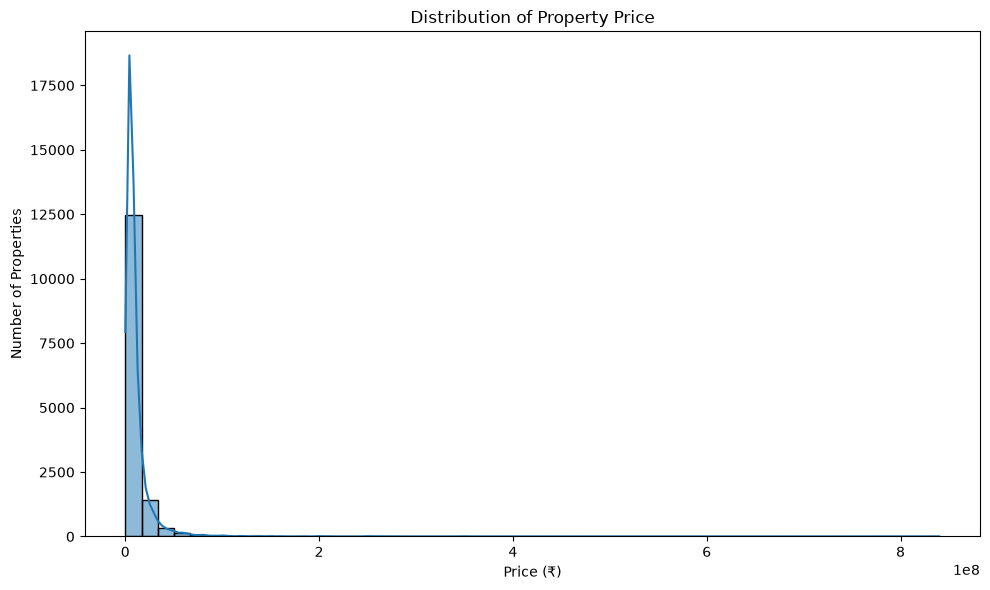

In [48]:
plt.figure(figsize=(10, 6))

sns.histplot(
    price_numeric_eda.dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Property Price")
plt.xlabel("Price (₹)")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

### Observation

The `Price` distribution is strongly right-skewed. Most properties are concentrated in the lower price range, while a small number of high-priced properties create a long right tail.

These extreme observations are not treated as errors at this stage because they may represent legitimate properties. Their characteristics will be investigated further during EDA.

A target transformation, if required, will be considered later during preprocessing and model evaluation.

## Total Area Distribution

`Total_Area` represents the size of the property and is a potentially important predictor of `Price`.

We will examine its distribution and identify whether the dataset contains unusually small or large property areas.

Extreme values will be investigated rather than automatically removed.

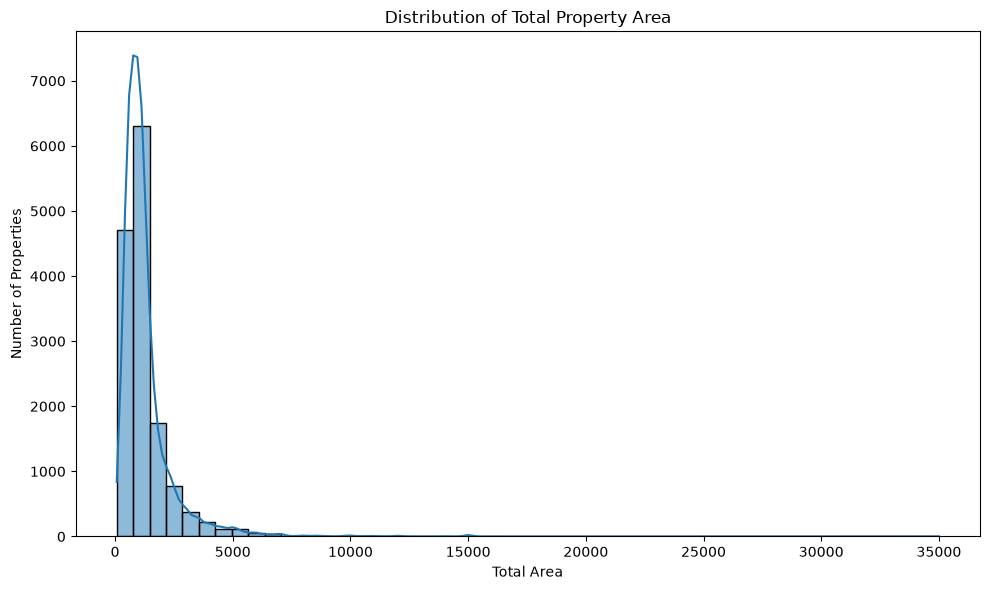

In [49]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["Total_Area"].dropna(),
    bins=50,
    kde=True
)

plt.title("Distribution of Total Property Area")
plt.xlabel("Total Area")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

### Observation

`Total_Area` is strongly right-skewed. Most properties have relatively smaller areas, while a smaller number of properties have substantially larger areas.

The large-area observations are not automatically considered invalid because they may represent legitimate large properties. Their relationship with `Price` will be investigated before deciding how they should be handled.

## Bath Distribution

`Baths` represents the number of bathrooms associated with a property.

We will examine its frequency distribution to understand the most common bathroom counts and whether unusual values are present.

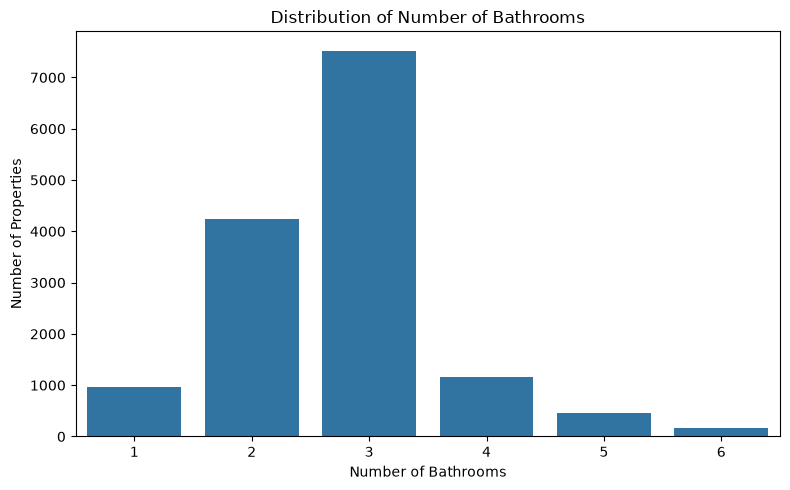

In [50]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Baths"
)

plt.title("Distribution of Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

### Observation

The dataset contains bathroom counts from 1 to 6, with 3 bathrooms being the most common and 2 bathrooms the second most common.

Higher bathroom counts are less frequent, but they may still provide useful information for predicting property price. The relationship between `Baths` and `Price` will be investigated separately.

## Balcony Distribution

`Balcony` is a categorical property characteristic indicating whether a property has a balcony.

We will examine its category distribution and determine whether both categories have enough observations for meaningful comparison with `Price`.

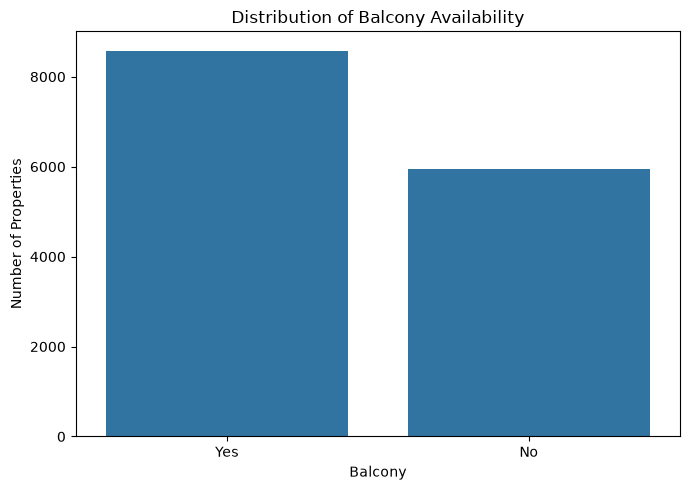

In [51]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Balcony"
)

plt.title("Distribution of Balcony Availability")
plt.xlabel("Balcony")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

### Observation

Both `Balcony` categories have a substantial number of observations, with `Yes` occurring more frequently than `No`.

The category distribution is suitable for further comparison with `Price`. However, this distribution alone does not indicate whether balcony availability affects property price.

## Location Distribution

`Location` is a categorical variable that may capture important differences in property prices.

Because it may contain many unique values, the analysis will first examine its cardinality and then visualize the most frequently occurring locations.

This analysis is exploratory; no location categories will be removed or grouped at this stage.

In [52]:
location_counts = df["Location"].value_counts(dropna=False)

print(f"Unique locations: {df['Location'].nunique(dropna=True):,}")
print(f"Most common location: {location_counts.index[0]}")
print(f"Properties in most common location: {location_counts.iloc[0]:,}")

location_counts.head(15)

Unique locations: 7,050
Most common location: Sector 12 Dwarka, New Delhi
Properties in most common location: 44


Location
Sector 12 Dwarka, New Delhi                        44
Wagholi, Pune                                      39
Bannerughatta, Bangalore                           35
Horamavu Agara, Horamavu,Bangalore                 32
Chakan, Pune                                       32
Veer Sandra, Electronic City,Bangalore             31
Mattanahalli, Bangalore                            31
Yelahanka, Bangalore                               30
Veer Sandra, Electronic City Phase II,Bangalore    29
Dodsworth Layout, Whitefield,Bangalore             27
Hindustan Antibiotics Colony, Pimpri,Pune          27
Srinivasa Nagar, Banashankari,Bangalore            26
Narhe, Pune                                        26
Avadi, Chennai                                     25
Veppampattu, Chennai                               25
Name: count, dtype: int64

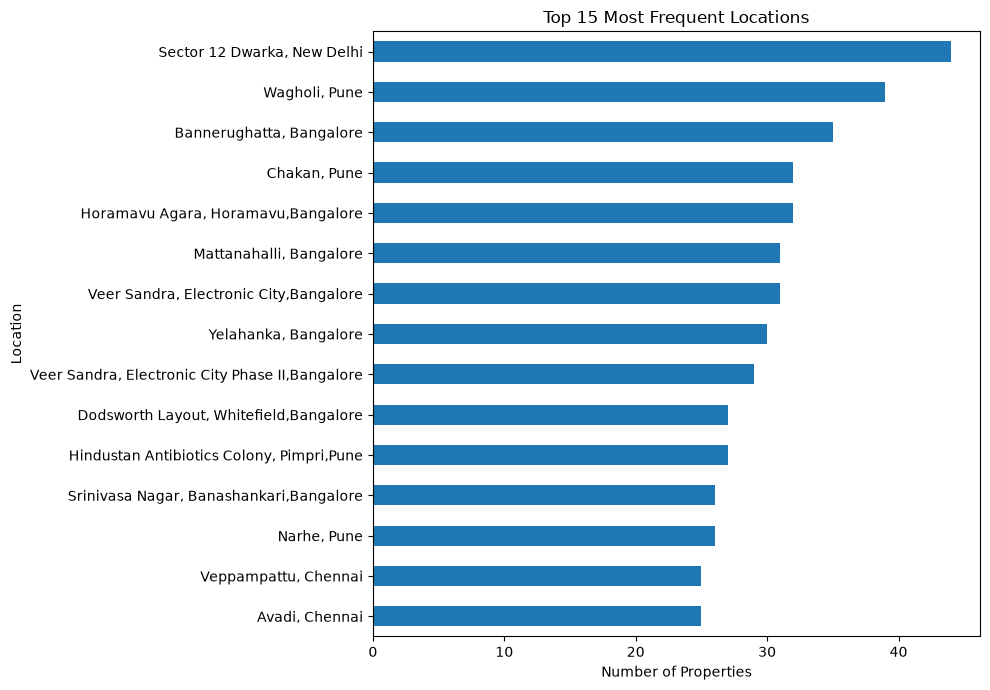

In [53]:
top_locations = location_counts.head(15).sort_values()

plt.figure(figsize=(10, 7))

top_locations.plot(kind="barh")

plt.title("Top 15 Most Frequent Locations")
plt.xlabel("Number of Properties")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

### Observation

`Location` has very high cardinality, with 7,050 unique values across 14,528 properties. Even the most frequent location contains only 44 properties.

This indicates that many location categories are sparsely represented. However, location may still contain important information about property prices, so its predictive usefulness should be investigated before deciding how to represent it.

## Location vs Price

Location may be an important determinant of property price because real-estate prices can vary substantially across geographic areas.

Because the dataset contains 7,050 unique locations with many sparsely represented categories, the analysis will focus on locations with a sufficient number of observations.

This helps avoid drawing conclusions from locations represented by only one or two properties.

In [54]:
eda_location_price = pd.DataFrame({
    "Location": df["Location"],
    "Price": price_numeric_eda
}).dropna(subset=["Location", "Price"])

location_price_summary = (
    eda_location_price
    .groupby("Location")
    .agg(
        Property_Count=("Price", "size"),
        Median_Price=("Price", "median"),
        Mean_Price=("Price", "mean")
    )
    .query("Property_Count >= 10")
    .sort_values("Property_Count", ascending=False)
)

print(f"Locations with at least 10 properties: {len(location_price_summary):,}")

location_price_summary.head(15)

Locations with at least 10 properties: 197


,Property_Count,Median_Price,Mean_Price
Location,,,
"Sector 12 Dwarka, New Delhi",44,25000000.0,2.786136e+07
"Wagholi, Pune",39,4490000.0,4.459436e+06
"Bannerughatta, Bangalore",35,4400000.0,9.514257e+06
"Chakan, Pune",32,2750000.0,3.004688e+06
"Horamavu Agara, Horamavu,Bangalore",32,8550000.0,1.234688e+07
"Veer Sandra, Electronic City,Bangalore",31,3700000.0,5.838710e+06
"Mattanahalli, Bangalore",31,6500000.0,9.675484e+06
"Yelahanka, Bangalore",30,6250000.0,7.060667e+06
"Veer Sandra, Electronic City Phase II,Bangalore",29,5800000.0,7.023793e+06


### Observation

Among locations with at least 10 properties, median property prices vary substantially across locations.

This suggests that `Location` may contain meaningful information for predicting `Price`. However, price differences may also be influenced by other property characteristics such as area, bathrooms, and property type.

Therefore, location should be investigated further rather than being automatically removed or treated as a simple low-cardinality category.

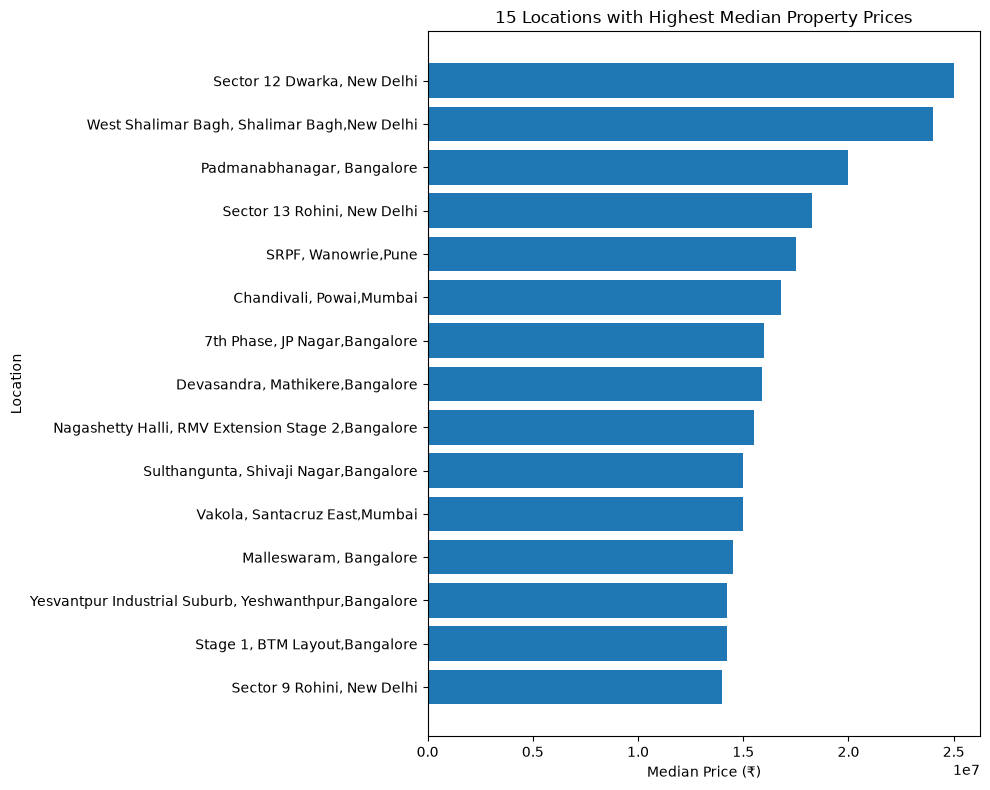

In [55]:
top_median_locations = (
    location_price_summary
    .sort_values("Median_Price", ascending=False)
    .head(15)
    .sort_values("Median_Price")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_median_locations.index,
    top_median_locations["Median_Price"]
)

plt.title("15 Locations with Highest Median Property Prices")
plt.xlabel("Median Price (₹)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

### Observation

The median property price varies substantially across locations with sufficient observations.

This indicates that `Location` may provide meaningful information for predicting `Price`. However, these differences may also reflect differences in property size, property type, and other characteristics.

The analysis is descriptive and does not imply that location alone determines property price.

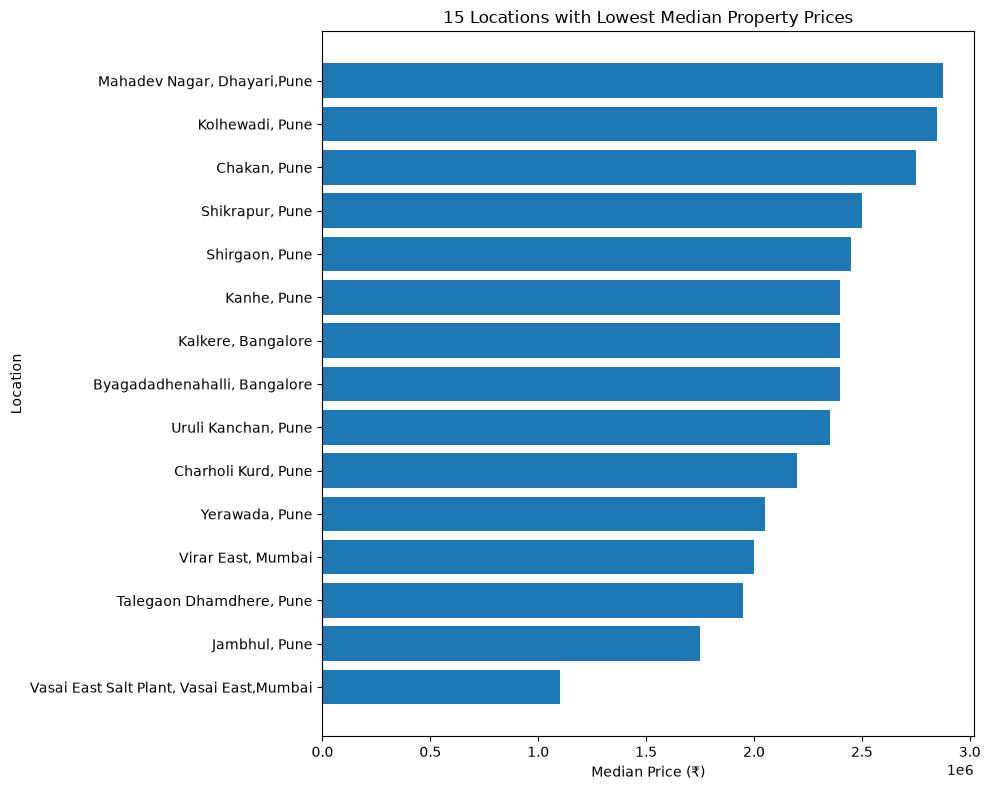

In [56]:
bottom_median_locations = (
    location_price_summary
    .sort_values("Median_Price", ascending=True)
    .head(15)
    .sort_values("Median_Price")
)

plt.figure(figsize=(10, 8))

plt.barh(
    bottom_median_locations.index,
    bottom_median_locations["Median_Price"]
)

plt.title("15 Locations with Lowest Median Property Prices")
plt.xlabel("Median Price (₹)")
plt.ylabel("Location")
plt.tight_layout()
plt.show()

### Observation

The lower-median locations also show substantial differences in typical property prices. Many of the locations shown are in Pune, while some are in Bangalore and Mumbai.

Together with the higher-median location analysis, this provides evidence that geographic location is associated with meaningful variation in property prices.

However, location effects may be influenced by other property characteristics such as area, bathrooms, and property type. Therefore, the relationship should be considered exploratory rather than causal.

## Total Area vs Price

This analysis examines the relationship between property area and price.

A positive relationship would indicate that larger properties tend to have higher prices. The scatter plot will also help identify unusual observations and whether the relationship appears approximately linear or more complex.

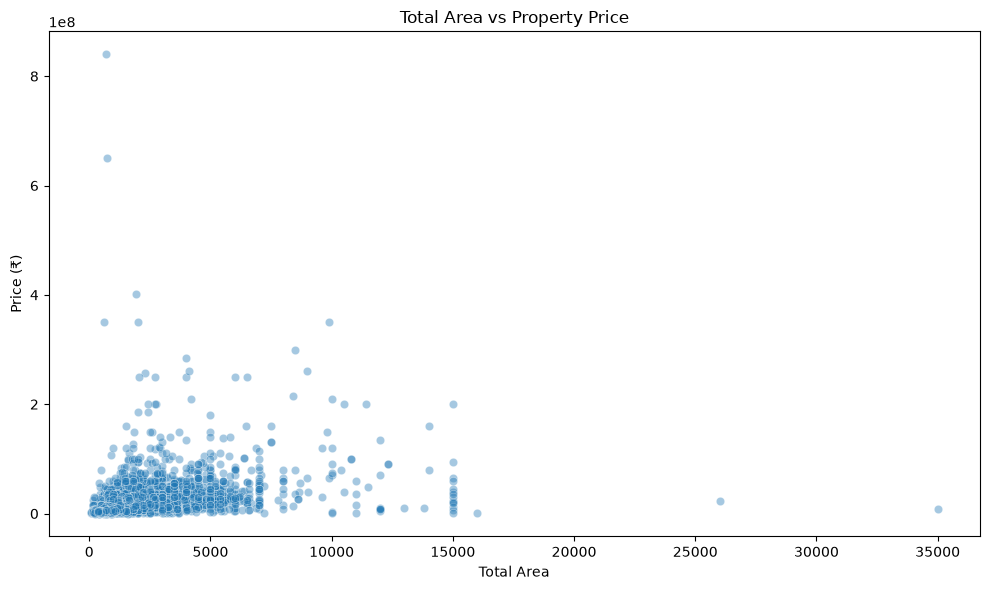

In [57]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pd.DataFrame({
        "Total_Area": df["Total_Area"],
        "Price": price_numeric_eda
    }),
    x="Total_Area",
    y="Price",
    alpha=0.4
)

plt.title("Total Area vs Property Price")
plt.xlabel("Total Area")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()

### Observation

The scatter plot shows a positive but highly variable relationship between `Total_Area` and `Price`.

Larger properties can have higher prices, but properties with similar areas can have substantially different prices. Several extreme observations also affect the overall pattern.

Therefore, `Total_Area` appears to contain useful price information, but it is not sufficient by itself to explain property prices. Other factors such as location, bathrooms, and property characteristics are likely important as well.

In [58]:
area_price_data = pd.DataFrame({
    "Total_Area": df["Total_Area"],
    "Price": price_numeric_eda
}).dropna()

pearson_corr = area_price_data["Total_Area"].corr(
    area_price_data["Price"],
    method="pearson"
)

spearman_corr = area_price_data["Total_Area"].corr(
    area_price_data["Price"],
    method="spearman"
)

print(f"Pearson correlation: {pearson_corr:.3f}")
print(f"Spearman correlation: {spearman_corr:.3f}")

Pearson correlation: 0.440
Spearman correlation: 0.692


### Correlation Observation

`Total_Area` shows a positive relationship with `Price`.

- Pearson correlation: **0.440**
- Spearman correlation: **0.692**

The Pearson correlation indicates a moderate linear relationship, while the higher Spearman correlation suggests a stronger overall monotonic relationship.

This indicates that larger properties generally tend to have higher prices, although the relationship is not purely linear and other property characteristics also influence price.

Therefore, `Total_Area` appears to be a promising predictor for further modeling.

## Bathrooms vs Price

This analysis examines how property prices vary across different numbers of bathrooms.

A box plot is used because `Baths` is a discrete variable and `Price` is strongly right-skewed. The comparison will help us understand differences in typical price and price variability across bathroom counts.

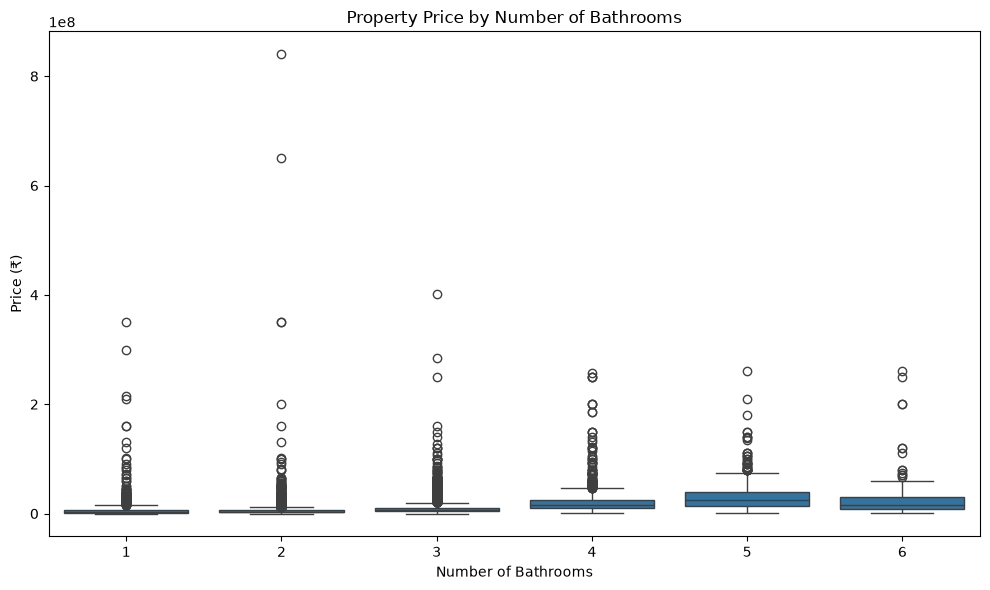

In [59]:
baths_price_data = pd.DataFrame({
    "Baths": df["Baths"],
    "Price": price_numeric_eda
}).dropna()

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=baths_price_data,
    x="Baths",
    y="Price"
)

plt.title("Property Price by Number of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()

### Observation

Property prices generally increase as the number of bathrooms increases, with properties having 4–6 bathrooms showing higher typical prices than those with fewer bathrooms.

However, there is substantial price variation within each bathroom group, along with several high-priced observations.

This suggests that `Baths` may provide useful information for predicting `Price`, but its effect should be considered together with other property characteristics such as `Total_Area` and `Location`.

## Balcony vs Price

This analysis examines whether property prices differ between properties with and without a balcony.

A box plot is used to compare the typical price, spread, and extreme observations across the two categories.

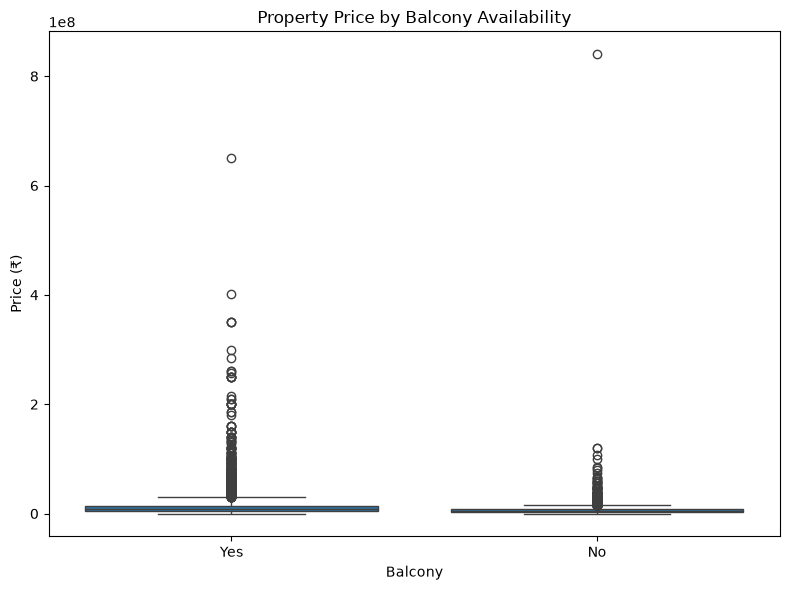

In [60]:
balcony_price_data = pd.DataFrame({
    "Balcony": df["Balcony"],
    "Price": price_numeric_eda
}).dropna()

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=balcony_price_data,
    x="Balcony",
    y="Price"
)

plt.title("Property Price by Balcony Availability")
plt.xlabel("Balcony")
plt.ylabel("Price (₹)")
plt.tight_layout()
plt.show()

### Observation

Properties with a balcony appear to have higher typical prices than properties without a balcony.

However, there is substantial variation within both groups, and several high-priced observations affect the overall distribution.

The difference should be quantified before deciding whether `Balcony` provides useful predictive information. The observed difference should also not be interpreted as a causal effect because other property characteristics may influence both balcony availability and price.

In [61]:
balcony_price_summary = (
    balcony_price_data
    .groupby("Balcony")["Price"]
    .agg(
        Property_Count="count",
        Median_Price="median",
        Mean_Price="mean"
    )
    .sort_values("Median_Price", ascending=False)
)

balcony_price_summary

,Property_Count,Median_Price,Mean_Price
Balcony,,,
Yes,8577,7500000.0,1.317528e+07
No,5948,5500000.0,7.068725e+06


### Observation

Properties with a balcony have a higher median price than properties without one:

- Balcony = `Yes`: median price of approximately **₹7.5 million**
- Balcony = `No`: median price of approximately **₹5.5 million**

This indicates an association between balcony availability and property price in the dataset.

However, this difference should not be interpreted as a causal effect because other factors such as `Location`, `Total_Area`, and property characteristics may also influence price.

Therefore, `Balcony` remains a potential predictive feature for further evaluation.

## Price per Square Foot Analysis

`Price_per_SQFT` is examined as an exploratory variable because it provides information about property price relative to area.

However, this variable is potentially derived from `Price` and `Total_Area` and was identified as a target-leakage risk during data validation.

Therefore, it will not be considered a predictive feature for the final `Price` model. This section is used only to understand its distribution and identify unusual observations.

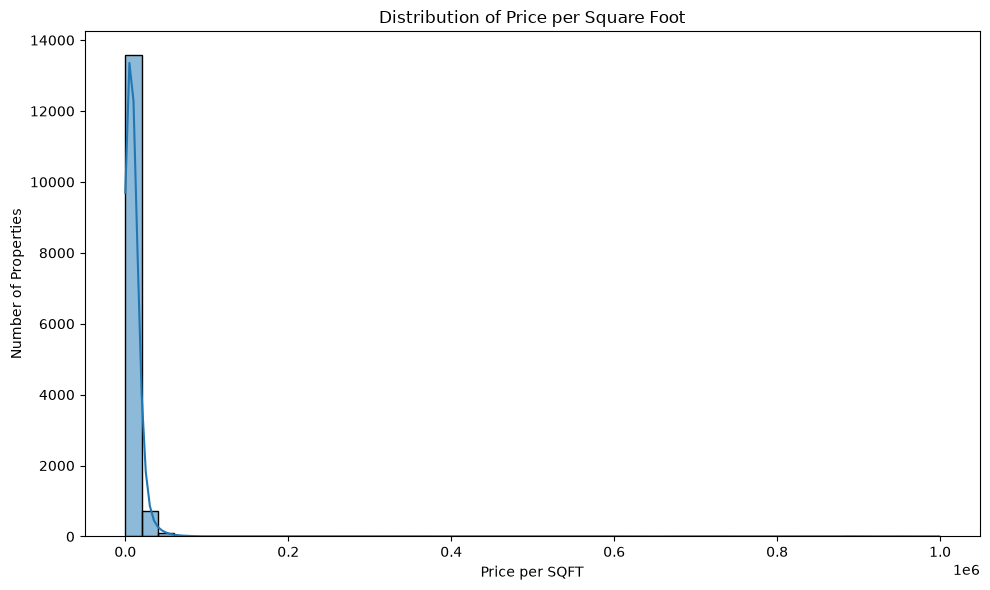

In [62]:
price_per_sqft = df["Price_per_SQFT"].dropna()

plt.figure(figsize=(10, 6))

sns.histplot(
    price_per_sqft,
    bins=50,
    kde=True
)

plt.title("Distribution of Price per Square Foot")
plt.xlabel("Price per SQFT")
plt.ylabel("Number of Properties")
plt.tight_layout()
plt.show()

### Observation

`Price_per_SQFT` is strongly right-skewed, with most observations concentrated at lower values and a small number of very high values.

The extreme observations require investigation, but they are not automatically considered invalid.

Most importantly, `Price_per_SQFT` remains excluded from the predictive feature set because it is strongly derived from the target `Price` and `Total_Area`.

In [63]:
price_per_sqft_extremes = (
    df[["Price", "Total_Area", "Price_per_SQFT", "Location"]]
    .sort_values("Price_per_SQFT", ascending=False)
    .head(15)
)

price_per_sqft_extremes

,Price,Total_Area,Price_per_SQFT,Location
12276,₹9.99 L,1000,999000.0,"lakefront,Uruli Kanchan, Pune"
5698,₹7.5 L,760,986000.0,"Richard Xavier's Colony, Neelasandra,Bangalore"
14380,₹3.8 L,390,974000.0,"rohini sec 4,Vijay Vihar Phase II, Sector 4 Ro..."
5809,₹10.0 L,1050,952000.0,"Marsur, Bangalore"
13943,₹19.0 L,2000,950000.0,"Chirag Dilli, New Delhi"
13817,₹5.1 L,540,944000.0,"Madanpur Khadar, New Delhi"
7724,₹3.0 L,320,937000.0,"Vasai East Salt Plant, Vasai East,Mumbai"
13436,₹1.5 L,160,937000.0,"Pocket F,Sector B-2, Narela,New Delhi"
4084,₹15.0 L,1600,937000.0,"Kamala Nagar, Bangalore"
5416,₹1.1 Cr,12000,916000.0,"Andrahalli, Bangalore"


### Observation

The extreme `Price_per_SQFT` records show very high reported values, and several examples appear inconsistent with the expected `Price / Total_Area` relationship.

These observations indicate that `Price_per_SQFT` may contain inconsistent or incorrectly represented values in addition to being target-derived.

Therefore, `Price_per_SQFT` will not be used as a predictive feature. The raw column will remain unchanged, and no records will be removed during EDA based only on these observations.

In [64]:
high_ppsf_count = (df["Price_per_SQFT"] > 100_000).sum()
zero_ppsf_count = (df["Price_per_SQFT"] == 0).sum()

print(f"Price_per_SQFT > 100,000: {high_ppsf_count:,}")
print(f"Price_per_SQFT = 0: {zero_ppsf_count:,}")

Price_per_SQFT > 100,000: 91
Price_per_SQFT = 0: 3


### Price per SQFT Observation

The `Price_per_SQFT` column contains 91 observations above 100,000 and 3 observations equal to zero.

Inspection of extreme records shows that some reported values are inconsistent with the expected relationship between `Price`, `Total_Area`, and price per square foot.

Because `Price_per_SQFT` is also potentially derived from the target variable `Price`, using it as a model feature could introduce target leakage.

Therefore, `Price_per_SQFT` will be excluded from the predictive feature set. The raw column will remain unchanged, and the identified records will be retained for further data-quality consideration rather than removed during EDA.

## Property Title Analysis

`Property Title` is a text field that may contain useful structured information about a property, such as bedroom count, property type, or other descriptive details.

Because the raw dataset does not contain a separate BHK column, this analysis will determine whether BHK information is consistently present in the title text.

No new features will be created at this stage. The purpose is to understand whether reliable feature extraction may be possible later.

In [65]:
print(f"Unique property titles: {df['Property Title'].nunique(dropna=True):,}")
print(f"Missing property titles: {df['Property Title'].isna().sum():,}")

df["Property Title"].value_counts(dropna=False).head(20)

Unique property titles: 6,507
Missing property titles: 0


Property Title
2 BHK Flat for sale in Electronic City, Bangalore             53
2 BHK Flat for sale in Hadapsar, Pune                         39
1 BHK Flat for sale in Mira Road East, Mumbai                 38
2 BHK Flat for sale in Mira Road East, Mumbai                 33
2 BHK Flat for sale in Wagholi, Pune                          31
2 BHK Flat for sale in Rajarhat, Kolkata                      29
2 BHK Flat for sale in Pimpri, Pune                           29
2 BHK Flat for sale in Whitefield, Bangalore                  28
2 BHK Flat for sale in JP Nagar, Bangalore                    28
2 BHK Flat for sale in Bommasandra, Bangalore                 27
2 BHK Flat for sale in Chandapura, Bangalore                  27
1 BHK Flat for sale in Dhayari, Pune                          27
2 BHK Flat for sale in Talegaon Dabhade, Pune                 27
2 BHK Flat for sale in HSR Layout, Bangalore                  26
2 BHK Flat for sale in Behala, Kolkata                        26
1 BHK Flat

### Observation

`Property Title` contains 6,507 unique values and has no missing values.

The title text contains repeated structured patterns, including bedroom information such as `1 BHK` and `2 BHK`, as well as property-type information such as `Flat`.

This suggests that useful structured features may be extractable from the title text. However, the consistency of these patterns must be checked before creating engineered features.

In [66]:
bhk_pattern = r"\b\d+\s*BHK\b"

bhk_present = df["Property Title"].str.contains(
    bhk_pattern,
    case=False,
    regex=True,
    na=False
)

print(f"Titles containing BHK information: {bhk_present.sum():,}")
print(f"Titles without BHK information: {(~bhk_present).sum():,}")
print(f"BHK information coverage: {bhk_present.mean() * 100:.2f}%")

Titles containing BHK information: 13,777
Titles without BHK information: 751
BHK information coverage: 94.83%


### BHK Pattern Observation

BHK information is present in **13,777 of 14,528 property titles (94.83%)**.

This high coverage indicates that BHK is a promising candidate for future feature engineering.

However, 751 titles do not contain a recognizable BHK pattern. These titles should be investigated before deciding how missing BHK information will be handled.

No BHK feature is created during EDA.

In [67]:
titles_without_bhk = df.loc[
    ~bhk_present,
    "Property Title"
]

titles_without_bhk.head(30).to_list()

['1 RK Flat for sale in Oragadam Sriperambattur, Chennai',
 '1 RK Flat for sale in Pallikaranai, Chennai',
 '1 RK Flat for sale in Manapakkam, Chennai',
 '1 RK Flat for sale in Padur, Chennai',
 '1 RK Flat for sale in Senganmal, Chennai',
 '1 RK Flat for sale in Moolakazhani, Chennai',
 '1 RK Flat for sale in Chettipunyam, Chennai',
 '1 RK Independent House for sale in Kosappur, Chennai',
 '1 RK Independent House for sale in Veppampattu, Chennai',
 '1 RK Flat for sale in Madambakkam, Chennai',
 '1 RK Flat for sale in Oragadam Sriperambattur, Chennai',
 '1 RK Flat for sale in Triplicane, Chennai',
 '1 RK Villa for sale in Kanchipuram, Chennai',
 '1 RK Flat for sale in Nemilicheri, Chennai',
 '5+ BHK Independent House for sale in Avadi, Chennai',
 '1 RK Flat for sale in West Mambalam, Chennai',
 '1 RK Independent House for sale in Poonamallee, Chennai',
 '1 RK Flat for sale in Virugambakkam, Chennai',
 '1 RK Flat for sale in Palavakkam, Chennai',
 '1 RK Flat for sale in Oragadam Sriperam

### BHK Pattern Investigation

The initial BHK pattern matched 94.83% of property titles. However, inspection of the remaining titles shows that some contain alternative structured terms such as `RK` and `Studio`.

Therefore, the 751 unmatched titles should not automatically be treated as missing BHK information. Some may represent different property configurations or use alternative terminology.

Further pattern analysis is required before deciding how bedroom-related information should be engineered.

In [68]:
rk_pattern = r"\b\d+\s*RK\b"
studio_pattern = r"\bStudio\b"
bhk_pattern = r"\b\d+\s*BHK\b"

pattern_summary = pd.DataFrame({
    "Pattern": ["BHK", "RK", "Studio"],
    "Matching Titles": [
        df["Property Title"].str.contains(
            bhk_pattern, case=False, regex=True, na=False
        ).sum(),
        df["Property Title"].str.contains(
            rk_pattern, case=False, regex=True, na=False
        ).sum(),
        df["Property Title"].str.contains(
            studio_pattern, case=False, regex=True, na=False
        ).sum()
    ]
})

pattern_summary["Coverage (%)"] = (
    pattern_summary["Matching Titles"] / len(df) * 100
).round(2)

pattern_summary

,Pattern,Matching Titles,Coverage (%)
0,BHK,13777,94.83
1,RK,706,4.86
2,Studio,11,0.08


### Property Configuration Pattern Observation

The `Property Title` field contains several structured property-configuration patterns:

- `BHK` appears in 13,777 titles (94.83%).
- `RK` appears in 706 titles (4.86%).
- `Studio` appears in 11 titles (0.08%).

These patterns cover approximately 99.77% of the dataset.

The results indicate that property configuration information can potentially be extracted from the title text. However, `BHK`, `RK`, and `Studio` represent different configurations and should not be automatically combined into a single numeric feature.

Feature extraction will be considered during the preprocessing and feature-engineering stage.

In [69]:
bhk_mask = df["Property Title"].str.contains(
    bhk_pattern, case=False, regex=True, na=False
)

rk_mask = df["Property Title"].str.contains(
    rk_pattern, case=False, regex=True, na=False
)

studio_mask = df["Property Title"].str.contains(
    studio_pattern, case=False, regex=True, na=False
)

pattern_overlap = pd.DataFrame({
    "BHK": bhk_mask,
    "RK": rk_mask,
    "Studio": studio_mask
})

pattern_overlap.value_counts().rename("Title Count")

BHK    RK     Studio
True   False  False     13777
False  True   False       706
       False  False        34
              True         11
Name: Title Count, dtype: int64

### Property Configuration Pattern Validation

The pattern analysis shows that `BHK`, `RK`, and `Studio` patterns do not overlap in the dataset.

- `BHK`: 13,777 titles
- `RK`: 706 titles
- `Studio`: 11 titles
- No recognized configuration pattern: 34 titles

This indicates that property configuration information is highly structured within `Property Title`.

The absence of overlap also makes separate feature extraction more straightforward during preprocessing. The 34 titles without a recognized configuration pattern will require separate handling if configuration features are created.

## Description Analysis

`Description` is a free-form text field that may contain additional information about a property, such as features, amenities, location details, or property characteristics.

Because free-form text can have high cardinality and substantial noise, its completeness, uniqueness, and length distribution will be examined before deciding whether it should be used for predictive modeling.

In [70]:
description_analysis = pd.DataFrame({
    "Metric": [
        "Missing descriptions",
        "Unique descriptions",
        "Total descriptions",
        "Unique percentage"
    ],
    "Value": [
        df["Description"].isna().sum(),
        df["Description"].nunique(dropna=True),
        len(df),
        round(
            df["Description"].nunique(dropna=True) / len(df) * 100,
            2
        )
    ]
})

description_analysis

,Metric,Value
0,Missing descriptions,0.00
1,Unique descriptions,14490.00
2,Total descriptions,14528.00
3,Unique percentage,99.74


### Observation

`Description` has no missing values and contains 14,490 unique values among 14,528 properties, giving a uniqueness rate of 99.74%.

This indicates that the field is highly individualized and behaves as free-form text rather than a conventional categorical variable.

Direct categorical encoding would therefore be inappropriate. Further analysis of description length and text characteristics is required before deciding whether any text-derived features should be retained.

In [71]:
description_length = df["Description"].astype(str).str.len()

print(description_length.describe())

count    14528.000000
mean       599.720402
std         20.873016
min        270.000000
25%        603.000000
50%        603.000000
75%        603.000000
max        603.000000
Name: Description, dtype: float64


In [72]:
description_length_counts = (
    description_length
    .value_counts()
    .sort_index()
)

description_length_counts.head(20)

Description
270    1
276    1
278    1
285    2
297    1
298    1
299    1
305    1
306    1
311    1
316    1
317    3
319    1
322    1
328    1
341    1
346    1
348    1
349    1
350    1
Name: count, dtype: int64

In [73]:
print(
    f"Descriptions with exactly 603 characters: "
    f"{(description_length == 603).sum():,}"
)

print(
    f"Percentage with exactly 603 characters: "
    f"{(description_length == 603).mean() * 100:.2f}%"
)

Descriptions with exactly 603 characters: 13,774
Percentage with exactly 603 characters: 94.81%


### Description Length Observation

The description field is highly standardized in length.

Approximately **94.81% of descriptions contain exactly 603 characters**, while the overall uniqueness rate is 99.74%.

This suggests that the descriptions may follow a common template with property-specific information embedded within the text.

Although the field may contain useful information, direct categorical treatment is inappropriate because of its very high cardinality. The potential value of text-derived features should therefore be considered separately during feature engineering.

In [74]:
print("Example with 603 characters:\n")
print(df.loc[description_length == 603, "Description"].iloc[0])

print("\n" + "=" * 100 + "\n")

print("Example with a different length:\n")
print(df.loc[description_length != 603, "Description"].iloc[0])

Example with 603 characters:

Best 4 BHK Apartment for modern-day lifestyle is now available for sale. No brokerage involved, Posted by Owner. Grab this 4 BHK property for sale in one of Chennai's top location, Kanathur Reddikuppam. It is situated on floor 13. The total number of floors in this Apartment is 14. The property price of this unit is Rs 1.99 Cr. The built-up area is 2583 Square feet. There are 4 bedrooms and 4 bathroom. It is an ideal location for young families with kids, as this property is close to Mount Litera Zee School, OMR, Chennai, Amelio Early Education - Siruseri, and Chennai Mathematical Institute. H...


Example with a different length:

One of the finest property in Moolacheri is now available for sale. This is a 3 BHK Villa posted directly by owner. Make it yours now. The price of this Villa is Rs 1.01 Cr. This Villa is spacious with a built-up area of 1782 Square feet. There are 3 bedrooms and 3 bathroom. This property ensures you are a quick distance away fr

### Description Observation and Leakage Assessment

Inspection of the actual descriptions shows that the field contains structured information that overlaps with existing dataset variables.

In particular, descriptions explicitly mention the property price and property area. Since `Price` is the prediction target, using the raw `Description` as a predictive feature would introduce a significant risk of target leakage.

The descriptions are also highly unique and largely standardized to a fixed length, suggesting template-based text with property-specific information.

Therefore, the raw `Description` field will be excluded from the predictive feature set. The raw column will remain unchanged for traceability, but it will not be passed directly to the final price-prediction model.

In [75]:
description_bhk_pattern = r"\b\d+\s*BHK\b"

description_bhk_present = df["Description"].astype(str).str.contains(
    description_bhk_pattern,
    case=False,
    regex=True,
    na=False
)

print(
    f"Descriptions containing BHK information: "
    f"{description_bhk_present.sum():,}"
)

print(
    f"BHK coverage in Description: "
    f"{description_bhk_present.mean() * 100:.2f}%"
)

Descriptions containing BHK information: 13,610
BHK coverage in Description: 93.68%


### Description vs Property Title

BHK information is present in 13,610 descriptions, giving a coverage of 93.68%.

Although `Description` contains useful property information, `Property Title` provides slightly higher BHK coverage at 94.83% and is more concise and structured.

Because `Description` also explicitly contains the target `Price` and other property attributes, it presents a significant target-leakage risk.

Therefore, `Description` will be excluded from the predictive feature set. If BHK-related feature engineering is performed later, `Property Title` will be preferred as the primary source.

## Numerical Feature Relationship Overview

A correlation analysis is used to summarize relationships among the numerical variables that may be considered for predictive modeling.

`Price_per_SQFT` is intentionally excluded because it is potentially derived from the target `Price` and `Total_Area`, creating a target-leakage risk.

Correlation measures association rather than causation and will be used only as an exploratory diagnostic.

In [76]:
numeric_eda = df[
    ["Total_Area", "Baths", "Price_per_SQFT"]
].copy()

numeric_eda["Price"] = price_numeric_eda

numeric_corr = numeric_eda[
    ["Total_Area", "Baths", "Price"]
].corr()

numeric_corr

,Total_Area,Baths,Price
Total_Area,1.000000,0.529589,0.439728
Baths,0.529589,1.000000,0.267504
Price,0.439728,0.267504,1.000000


### Correlation Observation

Among the numerical variables examined, `Total_Area` has the strongest linear association with `Price` (Pearson correlation = 0.440).

`Baths` also shows a positive relationship with `Price` (0.267), indicating that bathroom count may provide additional predictive information.

`Total_Area` and `Baths` have a moderate positive correlation of 0.529, which is expected because larger properties may contain more bathrooms. This correlation is not sufficiently high to treat the two variables as redundant at this stage.

These correlations are exploratory and do not imply causation.

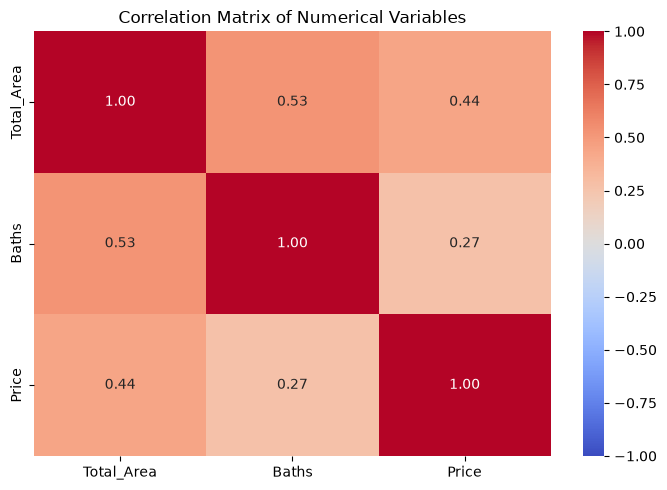

In [77]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    numeric_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

### Correlation Heatmap Observation

The correlation heatmap confirms the numerical relationships identified in the correlation table.

`Total_Area` has the strongest linear association with `Price`, while `Baths` has a weaker positive association.

The moderate correlation between `Total_Area` and `Baths` is reasonable because larger properties may contain more bathrooms. Neither variable shows sufficiently high correlation with another predictor to justify removing it at this stage.

Correlation analysis will be used as supporting EDA evidence rather than as the sole basis for feature selection.

## Name / Identifier Analysis

`Name` may represent a listing, project, or property identifier rather than a meaningful property characteristic.

Its uniqueness and repetition will be examined to determine whether it contains useful predictive information or should be excluded from the modeling feature set.

In [78]:
name_analysis = pd.DataFrame({
    "Metric": [
        "Missing Names",
        "Unique Names",
        "Total Names",
        "Unique Percentage"
    ],
    "Value": [
        df["Name"].isna().sum(),
        df["Name"].nunique(dropna=True),
        len(df),
        round(
            df["Name"].nunique(dropna=True) / len(df) * 100,
            2
        )
    ]
})

name_analysis

,Metric,Value
0,Missing Names,0.00
1,Unique Names,9998.00
2,Total Names,14528.00
3,Unique Percentage,68.82


In [79]:
name_counts = df["Name"].value_counts()

print(f"Unique names: {df['Name'].nunique():,}")
print(f"Names appearing more than once: {(name_counts > 1).sum():,}")
print(f"Names appearing only once: {(name_counts == 1).sum():,}")

name_counts.head(20)

Unique names: 9,998
Names appearing more than once: 1,939
Names appearing only once: 8,059


Name
Classic Apartment                                     42
DDA Flats                                             34
Veer Sandra, Electronic City,Bangalore                30
Bannerughatta, Bangalore                              25
Dharampura, Najafgarh,New Delhi                       20
Horamavu Agara, Horamavu,Bangalore                    19
Thotada Guddadhalli Village, Bangalore                18
Hindustan Antibiotics Colony, Pimpri,Pune             18
Srinivasa Nagar, Banashankari,Bangalore               17
Bommasandra Industrial Area, Bommasandra,Bangalore    17
Kithaganur Colony, Bangalore                          16
Uttam nagar west, Uttam Nagar,New Delhi               16
Guduvancheri, Chennai                                 15
Chakan, Pune                                          15
Maraimalai Nagar, Chennai                             14
Provident Welworth City                               14
Provident Sunworth                                    14
Hongasandra, Bangalore    

In [80]:
name_location_overlap = pd.DataFrame({
    "Name": df["Name"],
    "Location": df["Location"]
})

same_name_location = (
    name_location_overlap["Name"].str.strip().str.lower()
    == name_location_overlap["Location"].str.strip().str.lower()
)

print(
    f"Name exactly matching Location: "
    f"{same_name_location.sum():,}"
)

print(
    f"Percentage matching Location: "
    f"{same_name_location.mean() * 100:.2f}%"
)

Name exactly matching Location: 8,893
Percentage matching Location: 61.21%


### Name Observation and Feature Decision

`Name` contains 9,998 unique values across 14,528 properties, with 8,059 names appearing only once.

Additionally, 8,893 records (61.21%) have a `Name` value that exactly matches the corresponding `Location` value.

This indicates that `Name` is a high-cardinality field with substantial overlap with `Location`. Direct categorical encoding would create a sparse feature space while providing limited additional information.

Therefore, `Name` will be excluded from the initial predictive feature set. The raw column will remain unchanged for traceability, and the decision may be revisited if later model experiments provide evidence of additional predictive value.

# Final EDA Conclusion

The exploratory data analysis provided several important insights into the real-estate dataset and helped establish evidence-based decisions for the next stage of the machine-learning pipeline.

### Target Variable

The `Price` variable is strongly right-skewed. Most properties are concentrated in the lower price range, while a smaller number of high-priced properties create a long right tail. The raw `Price` column was not modified during EDA.

A temporary numeric representation was created only for analysis. Out of 14,528 records, 14,525 prices could be interpreted using recognized price formats, while 3 records remained ambiguous.

### Numerical Features

`Total_Area` shows a meaningful positive relationship with `Price`.

- Pearson correlation: **0.440**
- Spearman correlation: **0.692**

This indicates that larger properties generally tend to have higher prices, although the relationship is not purely linear.

`Baths` also shows a positive association with `Price`. Properties with more bathrooms generally have higher typical prices, but substantial variation exists within each bathroom group.

### Balcony

Properties with a balcony have a higher median price than properties without one:

- Balcony = `Yes`: approximately **₹7.5 million**
- Balcony = `No`: approximately **₹5.5 million**

This indicates that `Balcony` may contain useful predictive information, although the observed difference should not be interpreted as causal.

### Location

`Location` is a very high-cardinality feature with **7,050 unique values**.

Despite the high cardinality, substantial differences in median property prices were observed across sufficiently represented locations. Therefore, `Location` appears potentially valuable for prediction but will require a careful representation strategy during feature engineering.

### Property Title

`Property Title` contains highly structured property-configuration information.

Observed patterns include:

- `BHK`: 13,777 titles (94.83%)
- `RK`: 706 titles (4.86%)
- `Studio`: 11 titles (0.08%)

These patterns do not overlap in the dataset and indicate that useful property-configuration features may be extracted during preprocessing.

No such features were created during EDA.

### Description

`Description` is highly unique, with **14,490 unique descriptions (99.74%)**.

Approximately **94.81%** of descriptions contain exactly 603 characters, suggesting a standardized or template-based structure.

Inspection of actual descriptions showed that they explicitly contain information such as `Price`, `Total_Area`, BHK, and other property characteristics. Using the raw description as a model input would therefore create a significant target-leakage risk.

`Description` will be excluded from the predictive feature set.

### Price_per_SQFT

`Price_per_SQFT` was identified as a target-leakage risk because it is potentially derived from `Price` and `Total_Area`.

EDA also identified data-quality concerns:

- 91 values greater than 100,000
- 3 values equal to zero
- several extreme records appeared inconsistent with the expected `Price / Total_Area` relationship

Therefore, `Price_per_SQFT` will be excluded from the predictive feature set.

### Name

`Name` contains 9,998 unique values, with 8,059 names appearing only once.

Additionally, **61.21%** of records have a `Name` value that exactly matches `Location`.

Because of its high cardinality and substantial overlap with `Location`, `Name` will be excluded from the initial predictive feature set.

### Preliminary Feature Decisions

| Column | Decision | Reason |
|---|---|---|
| `Name` | Exclude | High cardinality and substantial overlap with `Location` |
| `Property Title` | Engineer later | Contains structured BHK/RK/Studio information |
| `Price` | Target | Prediction target |
| `Location` | Engineer later | High cardinality but potentially strong geographic signal |
| `Total_Area` | Candidate | Meaningful positive relationship with price |
| `Price_per_SQFT` | Exclude | Target leakage and data-quality concerns |
| `Description` | Exclude | Contains explicit target information |
| `Baths` | Candidate | Positive association with price |
| `Balcony` | Candidate | Meaningful difference in price distributions |

### Overall Conclusion

EDA shows that property price is influenced by multiple characteristics rather than a single variable.

`Total_Area`, `Baths`, `Balcony`, and `Location` appear promising for further modeling, while `Property Title` contains information that may be converted into structured features during preprocessing.

`Name`, `Description`, and `Price_per_SQFT` will not be used directly as predictive features because of high cardinality, redundancy, or target-leakage concerns.

No raw data was modified or removed during EDA. Any transformations or feature engineering identified through this analysis will be implemented later in the preprocessing stage.

The next milestone is to design a reproducible preprocessing and feature-engineering pipeline while keeping the raw dataset immutable.